# Laboratorio 3
## Sebastian Huertas 22295
## Sofia Velasquez 22049

# Parte 1

In [1]:
import os
import subprocess
import itertools
import pefile
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MultiLabelBinarizer

In [2]:
# Agregar strings
def extraer_strings(fullpath, min_length=4):
    try:
        resultado = subprocess.run(
            ["strings", "-n", str(min_length), fullpath],
            capture_output=True,
            text=True
        )
        return list(set(s.strip() for s in resultado.stdout.splitlines() if s.strip()))
    except Exception as e:
        print(f"  Error extrayendo strings en {os.path.basename(fullpath)}: {e}")
        return []
    
def extraer_features_pe(fullpath):
    features = {
        'archivo': os.path.basename(fullpath),
        'path': fullpath,
        'empaquetado': False,
        'razon_packing': 'No empaquetado',
        'num_secciones': 0,
        'imports': [],
        'dlls': [],
        'strings': [],
        'entropia_promedio': 0.0,
        'tam_code': 0,
        'tam_data': 0,
        'num_exports': 0,
        'subsistema': '',
        'arquitectura': ''
    }

    PACKER_SECTIONS = {b'UPX0', b'UPX1', b'UPX2', b'.packed', b'PECompact'}

    try:
        pe = pefile.PE(fullpath)

        features['num_secciones'] = len(pe.sections)
        features['tam_code'] = pe.OPTIONAL_HEADER.SizeOfCode
        features['tam_data'] = pe.OPTIONAL_HEADER.SizeOfInitializedData
        features['subsistema'] = str(pe.OPTIONAL_HEADER.Subsystem)
        features['arquitectura'] = hex(pe.FILE_HEADER.Machine)

        entropias = []
        for section in pe.sections:
            name = section.Name.rstrip(b'\x00')
            if name in PACKER_SECTIONS:
                features['empaquetado'] = True
                features['razon_packing'] = f'Seccion packer: {name.decode(errors="ignore")}'
            e = section.get_entropy()
            entropias.append(e)
            if e > 7.0 and not features['empaquetado']:
                features['empaquetado'] = True
                features['razon_packing'] = f'Alta entropia ({e:.2f}) en {name.decode(errors="ignore")}'

        features['entropia_promedio'] = round(np.mean(entropias), 4) if entropias else 0.0

        if hasattr(pe, 'DIRECTORY_ENTRY_IMPORT'):
            for entry in pe.DIRECTORY_ENTRY_IMPORT:
                dll = entry.dll.decode('utf-8', errors='ignore')
                features['dlls'].append(dll)
                for imp in entry.imports:
                    if imp.name:
                        features['imports'].append(imp.name.decode('utf-8', errors='ignore'))

        if hasattr(pe, 'DIRECTORY_ENTRY_EXPORT'):
            features['num_exports'] = len(pe.DIRECTORY_ENTRY_EXPORT.symbols)

    except Exception as e:
        print(f"  Error en {os.path.basename(fullpath)}: {e}")
    features['strings'] = extraer_strings(fullpath)
    return features

In [3]:
def is_pe(fullpath):
    try:
        with open(fullpath, 'rb') as f:
            return f.read(2) == b'MZ'
    except:
        return False
    
DATASET_PATH = "/home/kali/Desktop/Security-Data-Science/lab3/MALWR_lab3"  # Agregar en donde lo tienes

registros = []

for root, dirs, files in os.walk(DATASET_PATH):
    for fname in files:
        fpath = os.path.join(root, fname)
        if not is_pe(fpath):
            print(f"Omitido (no PE): {fname}")
            continue
        print(f"Procesando: {fname}")
        features = extraer_features_pe(fpath)
        registros.append(features)

df_raw = pd.DataFrame(registros)
print(f"\nTotal ejecutables procesados: {len(df_raw)}")
df_raw.head()

Procesando: F6655E39465C2FF5B016980D918EA028
Procesando: GBV66_8F259BB36E00D124963CFA9B86F502E
Procesando: FGTR43_EF8E0FB20E7228C7492CCDC59D87C690
Procesando: VC990_468FF2C12CFFC7E5B2FE0EE6BB3B239E
Procesando: VBMM9_149B7BD7218AAB4E257D28469FDDB0D
Procesando: PL98_BD8B082B7711BC980252F988BB0CA936
Procesando: SAM_B659D71AE168E774FAAF38DB30F4A84
Procesando: K99_C3A9A7B026BFE0E55FF219FD6AA7D94
Procesando: QW2_4C6BDDCCA2695D6202DF38708E14FC7E
Procesando: 6FAA4740F99408D4D2DDDD0B09BBDEFD
Procesando: 785003A405BC7A4EBCBB21DDB757BF3F
Procesando: NV99_C9C9DBF388A8D81D8CFB4D3FC05F8E4
Procesando: JH78C0A33A1B472A8C16123FD696A5CE5EBB
Procesando: POL55_A4F1ECC4D25B33395196B5D51A06790
Procesando: 65018CD542145A3792BA09985734C12A
Procesando: 99A39866A657A10949FCB6D634BB30D5
Procesando: B07322743778B5868475DBE66EEDAC4F
Procesando: BVJ2D9FBF759F527AF373E34673DC3ACA462
Procesando: FHHH6576C196385407B0F7F4B1B537D88983
Procesando: L11_1415EB8519D13328091CC5C76A624E3D
Procesando: NBV_8B75BCBFF174C25A0161F

,archivo,path,empaquetado,razon_packing,num_secciones,imports,dlls,strings,entropia_promedio,tam_code,tam_data,num_exports,subsistema,arquitectura
0,F6655E39465C2FF5B016980D918EA028,/home/kali/Desktop/Security-Data-Science/lab3/...,True,Seccion packer: UPX1,3,"[LoadLibraryA, ExitProcess, GetProcAddress, Vi...","[KERNEL32.DLL, MSVCRT.dll, USER32.dll, WS2_32....","[WaitForSing, ? Q;, %tfw, f#@StartXInfoA, <CS~...",3.3840,4096,4096,0,2,0x14c
1,GBV66_8F259BB36E00D124963CFA9B86F502E,/home/kali/Desktop/Security-Data-Science/lab3/...,False,No empaquetado,3,"[CreateFileA, LocalAlloc, Sleep, CreateThread,...","[KERNEL32.dll, USER32.dll, ADVAPI32.dll, SHELL...","[__getmainargs, PPhb""@, $,T@, %s-%s, CreateMut...",4.8849,9728,4010496,0,2,0x14c
2,FGTR43_EF8E0FB20E7228C7492CCDC59D87C690,/home/kali/Desktop/Security-Data-Science/lab3/...,True,Seccion packer: UPX1,3,"[RegSaveKeyA, BitBlt, LoadLibraryA, GetProcAdd...","[ADVAPI32.dll, GDI32.dll, KERNEL32.DLL, MSVCRT...","[jA1Nm, P9^I, v{3s %, jYg8, gK99r, 6mh%, 4&t5,...",3.7619,294912,4096,5,2,0x14c
3,VC990_468FF2C12CFFC7E5B2FE0EE6BB3B239E,/home/kali/Desktop/Security-Data-Science/lab3/...,True,Seccion packer: UPX2,3,"[RegSaveKeyA, BitBlt, LoadLibraryA, ExitProces...","[ADVAPI32.dll, GDI32.dll, KERNEL32.DLL, MSVCRT...","[Pep^nk*, *]L., \PRRI, V);u, ^pIBm, .$<X!k, <<...",3.4174,348160,4096,0,2,0x14c
4,VBMM9_149B7BD7218AAB4E257D28469FDDB0D,/home/kali/Desktop/Security-Data-Science/lab3/...,True,Seccion packer: UPX1,3,"[LoadLibraryA, ExitProcess, GetProcAddress, Vi...","[KERNEL32.DLL, MSVCRT.dll, SHELL32.dll, WININE...","[t#):, 4cjx, )hh}, _JFo, NECT'{I, |)J$, 7\tge,...",3.4442,12288,4096,0,2,0x14c


## Exploracion de datos

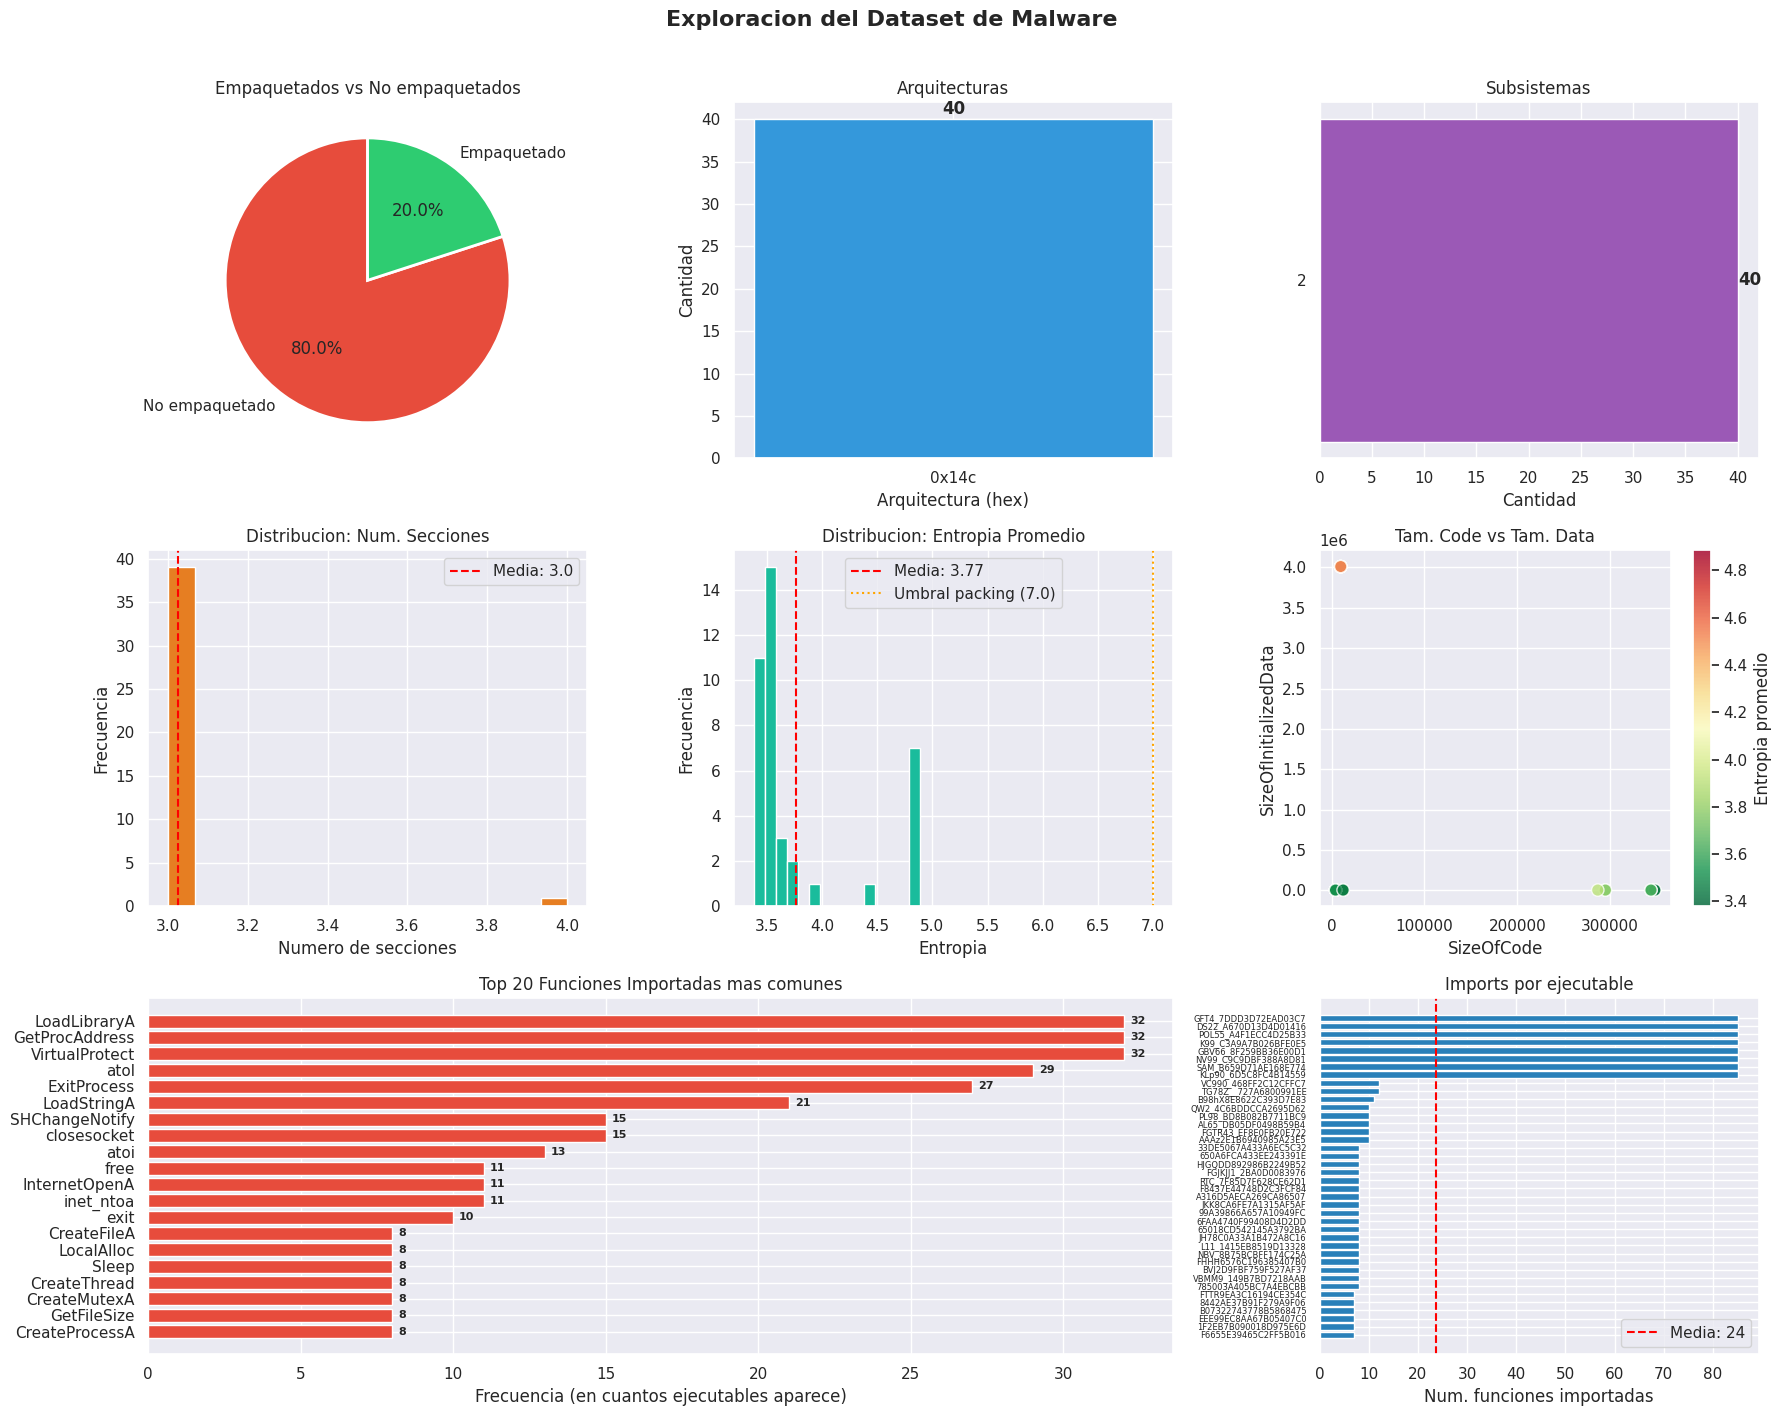

In [4]:
sns.set_theme(style="darkgrid")
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 3, figure=fig)
fig.suptitle("Exploracion del Dataset de Malware", fontsize=16, fontweight='bold', y=1.01)

# empaquetados vs no empaquetados
ax1 = fig.add_subplot(gs[0, 0])
pack_counts = df_raw['empaquetado'].value_counts()
colors = ['#e74c3c', '#2ecc71']
ax1.pie(pack_counts, labels=['No empaquetado', 'Empaquetado'], autopct='%1.1f%%',
        colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax1.set_title("Empaquetados vs No empaquetados")

# arquitecturas
ax2 = fig.add_subplot(gs[0, 1])
arch_counts = df_raw['arquitectura'].value_counts()
bars = ax2.bar(arch_counts.index, arch_counts.values, color='#3498db', edgecolor='white')
for bar, val in zip(bars, arch_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(val), ha='center', va='bottom', fontweight='bold')
ax2.set_title("Arquitecturas")
ax2.set_xlabel("Arquitectura (hex)")
ax2.set_ylabel("Cantidad")

# subsistemas
ax3 = fig.add_subplot(gs[0, 2])
sub_counts = df_raw['subsistema'].value_counts()
ax3.barh(sub_counts.index.astype(str), sub_counts.values, color='#9b59b6', edgecolor='white')
for i, val in enumerate(sub_counts.values):
    ax3.text(val + 0.1, i, str(val), va='center', fontweight='bold')
ax3.set_title("Subsistemas")
ax3.set_xlabel("Cantidad")

# -distribucion numero de secciones
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(df_raw['num_secciones'], bins=15, color='#e67e22', edgecolor='white')
ax4.axvline(df_raw['num_secciones'].mean(), color='red', linestyle='--', label=f"Media: {df_raw['num_secciones'].mean():.1f}")
ax4.set_title("Distribucion: Num. Secciones")
ax4.set_xlabel("Numero de secciones")
ax4.set_ylabel("Frecuencia")
ax4.legend()

# distribucion entropia promedio
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(df_raw['entropia_promedio'], bins=15, color='#1abc9c', edgecolor='white')
ax5.axvline(df_raw['entropia_promedio'].mean(), color='red', linestyle='--',
            label=f"Media: {df_raw['entropia_promedio'].mean():.2f}")
ax5.axvline(7.0, color='orange', linestyle=':', label="Umbral packing (7.0)")
ax5.set_title("Distribucion: Entropia Promedio")
ax5.set_xlabel("Entropia")
ax5.set_ylabel("Frecuencia")
ax5.legend()

# tam code vs tam data scatter 
ax6 = fig.add_subplot(gs[1, 2])
sc = ax6.scatter(df_raw['tam_code'], df_raw['tam_data'],
                 c=df_raw['entropia_promedio'], cmap='RdYlGn_r',
                 alpha=0.8, edgecolors='white', s=80)
plt.colorbar(sc, ax=ax6, label='Entropia promedio')
ax6.set_title("Tam. Code vs Tam. Data")
ax6.set_xlabel("SizeOfCode")
ax6.set_ylabel("SizeOfInitializedData")

# top 20 imports mas comunes 
ax7 = fig.add_subplot(gs[2, :2])
all_imports = [imp for imps in df_raw['imports'] for imp in imps]
import_series = pd.Series(all_imports).value_counts().head(20)
bars7 = ax7.barh(import_series.index[::-1], import_series.values[::-1], color='#e74c3c', edgecolor='white')
for bar, val in zip(bars7, import_series.values[::-1]):
    ax7.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontweight='bold', fontsize=8)
ax7.set_title("Top 20 Funciones Importadas mas comunes")
ax7.set_xlabel("Frecuencia (en cuantos ejecutables aparece)")

# num imports por archivo 
ax8 = fig.add_subplot(gs[2, 2])
num_imports = df_raw['imports'].apply(len).sort_values()
labels = df_raw.loc[num_imports.index, 'archivo'].apply(lambda x: x[:20])
ax8.barh(range(len(num_imports)), num_imports.values, color='#2980b9', edgecolor='white')
ax8.set_yticks(range(len(num_imports)))
ax8.set_yticklabels(labels, fontsize=6)
ax8.axvline(num_imports.mean(), color='red', linestyle='--', label=f"Media: {num_imports.mean():.0f}")
ax8.set_title("Imports por ejecutable")
ax8.set_xlabel("Num. funciones importadas")
ax8.legend()

plt.tight_layout()
plt.savefig("exploracion_dataset.png", dpi=150, bbox_inches='tight')
plt.show()

## Preprocesamiento 

In [5]:
cols_numericas = ['num_secciones', 'entropia_promedio', 'tam_code', 'tam_data', 'num_exports']

df_num = df_raw[cols_numericas].copy().fillna(0)

scaler = StandardScaler()
df_num_scaled = pd.DataFrame(scaler.fit_transform(df_num), columns=cols_numericas)
df_num_scaled.head()

,num_secciones,entropia_promedio,tam_code,tam_data,num_exports
0,-0.160128,-0.729364,-0.514776,-0.50000,-0.377964
1,-0.160128,2.128661,-0.470880,1.99988,-0.377964
2,-0.160128,-0.009764,1.751834,-0.50000,2.645751
3,-0.160128,-0.665763,2.166847,-0.50000,-0.377964
4,-0.160128,-0.614731,-0.450928,-0.50000,-0.377964


In [6]:
df_cat = pd.get_dummies(df_raw[['arquitectura', 'subsistema']], dtype=int)
df_cat.head()

,arquitectura_0x14c,subsistema_2
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1


In [7]:
mlb = MultiLabelBinarizer()
imports_matrix = mlb.fit_transform(df_raw['imports'])
df_imports = pd.DataFrame(imports_matrix, columns=mlb.classes_)

print(f"Vocabulario de imports: {len(mlb.classes_)} funciones unicas")
df_imports

Vocabulario de imports: 117 funciones unicas


,BitBlt,ChangeServiceConfig2A,CloseHandle,CloseServiceHandle,CopyFileA,CopyFileW,CreateFileA,CreateMutexA,CreateProcessA,CreateServiceA,...,strcpy,strlen,strstr,time,wcscat,wcscmp,wcscpy,wcslen,wcsrchr,wcstombs
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,1,1,1,1,0,...,1,1,1,1,1,1,1,1,1,1
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,1,0,0,1,1,1,1,0,...,1,1,1,1,1,1,1,1,1,1
7,0,0,1,0,0,1,1,1,1,0,...,1,1,1,1,1,1,1,1,1,1
8,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
df_features = pd.concat([
    df_num_scaled.reset_index(drop=True),
    df_cat.reset_index(drop=True),
    df_imports.reset_index(drop=True)
], axis=1)

df_features.index = df_raw['archivo'].values

print("Shape final del dataset:", df_features.shape)
df_features.head()

Shape final del dataset: (40, 124)


,num_secciones,entropia_promedio,tam_code,tam_data,num_exports,arquitectura_0x14c,subsistema_2,BitBlt,ChangeServiceConfig2A,CloseHandle,...,strcpy,strlen,strstr,time,wcscat,wcscmp,wcscpy,wcslen,wcsrchr,wcstombs
F6655E39465C2FF5B016980D918EA028,-0.160128,-0.729364,-0.514776,-0.50000,-0.377964,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GBV66_8F259BB36E00D124963CFA9B86F502E,-0.160128,2.128661,-0.470880,1.99988,-0.377964,1,1,0,0,1,...,1,1,1,1,1,1,1,1,1,1
FGTR43_EF8E0FB20E7228C7492CCDC59D87C690,-0.160128,-0.009764,1.751834,-0.50000,2.645751,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
VC990_468FF2C12CFFC7E5B2FE0EE6BB3B239E,-0.160128,-0.665763,2.166847,-0.50000,-0.377964,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
VBMM9_149B7BD7218AAB4E257D28469FDDB0D,-0.160128,-0.614731,-0.450928,-0.50000,-0.377964,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Parte 2
## Clustering con algoritmos de partición

En esta sección se aplican dos algoritmos de partición, K-Means y K-Medoids, sobre el dataset preprocesado. Primero se utiliza el método del codo para observar el comportamiento del error conforme cambia el número de clústeres. Luego se calcula el coeficiente de Silhouette para determinar de mejor manera el valor de K más apropiado. Finalmente, se etiqueta cada observación con el clúster asignado por ambos algoritmos.

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn_extra.cluster import KMedoids
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA


### Método del codo

Se calcula el error para distintos valores de K utilizando K-Means y K-Medoids. En K-Means se usa la inercia, mientras que en K-Medoids se usa el costo interno del modelo. Esto permite observar en qué punto el beneficio de aumentar K comienza a disminuir.

In [10]:
X = df_features.values
k_values = range(2, 11)

kmeans_inertia = []
kmedoids_inertia = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    kmeans_inertia.append(km.inertia_)

    kmed = KMedoids(n_clusters=k, random_state=42, metric='euclidean')
    kmed.fit(X)
    kmedoids_inertia.append(kmed.inertia_)

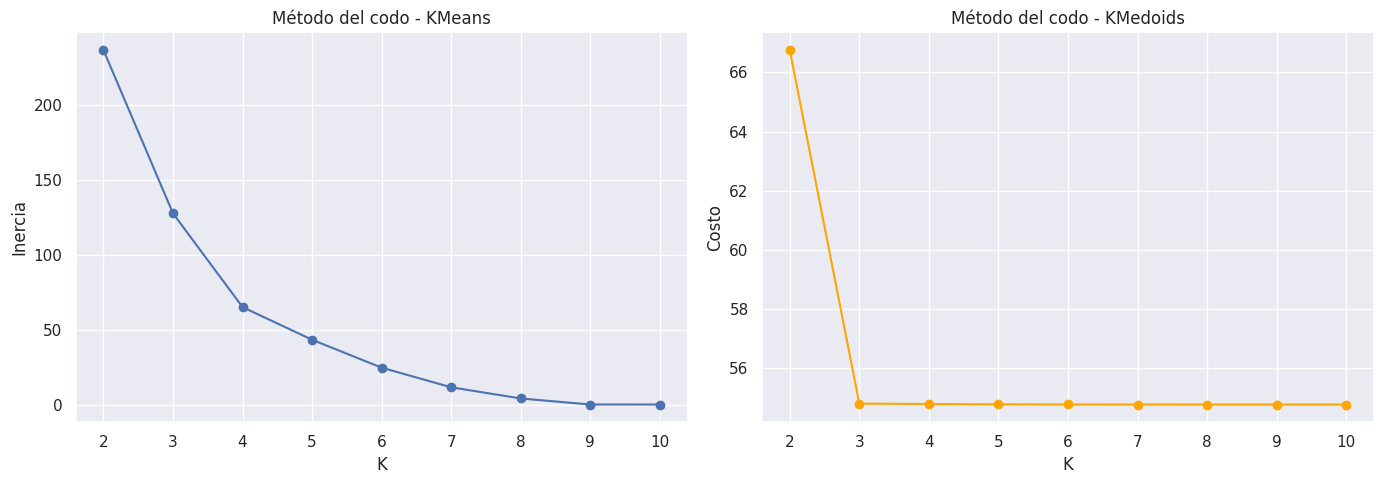

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(list(k_values), kmeans_inertia, marker='o')
ax[0].set_title("Método del codo - KMeans")
ax[0].set_xlabel("K")
ax[0].set_ylabel("Inercia")

ax[1].plot(list(k_values), kmedoids_inertia, marker='o', color='orange')
ax[1].set_title("Método del codo - KMedoids")
ax[1].set_xlabel("K")
ax[1].set_ylabel("Costo")

plt.tight_layout()
plt.show()

### Coeficiente de Silhouette

Después del método del codo, se calcula el coeficiente de Silhouette para distintos valores de K. Esta métrica permite evaluar qué tan compactos y separados están los clústeres. Un valor más alto indica una mejor partición.

In [12]:
kmeans_sil = []
kmedoids_sil = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_labels = km.fit_predict(X)
    kmeans_sil.append(silhouette_score(X, km_labels))

    kmed = KMedoids(n_clusters=k, random_state=42, metric='euclidean')
    kmed_labels = kmed.fit_predict(X)
    kmedoids_sil.append(silhouette_score(X, kmed_labels))

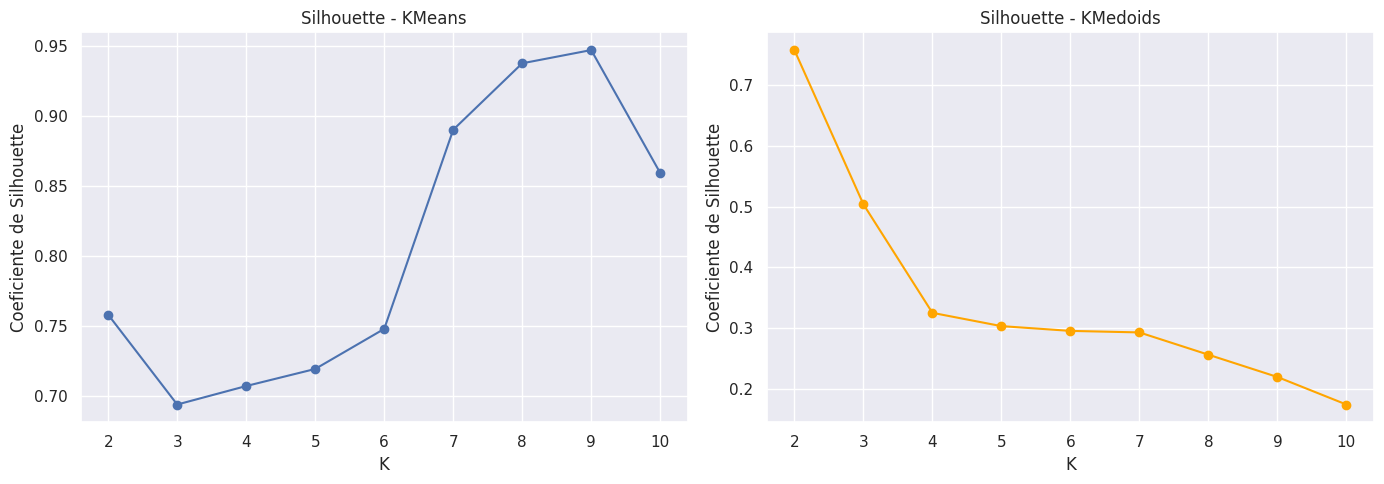

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(list(k_values), kmeans_sil, marker='o')
ax[0].set_title("Silhouette - KMeans")
ax[0].set_xlabel("K")
ax[0].set_ylabel("Coeficiente de Silhouette")

ax[1].plot(list(k_values), kmedoids_sil, marker='o', color='orange')
ax[1].set_title("Silhouette - KMedoids")
ax[1].set_xlabel("K")
ax[1].set_ylabel("Coeficiente de Silhouette")

plt.tight_layout()
plt.show()

### Selección del número óptimo de clústeres

Para K-Means, el método del codo muestra un punto en el que se suaviza la caida en 9, lo cual concuerda al analizar el coeficiente de Silhouette, el valor máximo se obtiene en K=9, por lo que se toma este valor como el número óptimo de clústeres para este algoritmo.

En el caso de K-Medoids, el método del codo sugiere un posible valor cercano a K=3, ya que después de este punto el costo deja de disminuir significativamente. No obstante, el coeficiente de Silhouette alcanza su valor máximo en K=2 y luego disminuye de forma constante, por lo que se selecciona K=2 como el valor óptimo final para K-Medoids.

### Selección del número de clústeres

A partir de las gráficas del método del codo y del coeficiente de Silhouette, se selecciona un valor de K para cada algoritmo. Este valor debe balancear una reducción razonable del error y una buena separación entre grupos.

In [14]:
K_OPT_KMEANS = 9
K_OPT_KMEDOIDS = 2

X = df_features.values

kmeans_final = KMeans(n_clusters=K_OPT_KMEANS, random_state=42, n_init=10)
df_raw['cluster_kmeans'] = kmeans_final.fit_predict(X)

kmedoids_final = KMedoids(n_clusters=K_OPT_KMEDOIDS, random_state=42, metric='euclidean')
df_raw['cluster_kmedoids'] = kmedoids_final.fit_predict(X)

df_raw[['archivo', 'cluster_kmeans', 'cluster_kmedoids']].head(10)

,archivo,cluster_kmeans,cluster_kmedoids
0,F6655E39465C2FF5B016980D918EA028,6,1
1,GBV66_8F259BB36E00D124963CFA9B86F502E,2,0
2,FGTR43_EF8E0FB20E7228C7492CCDC59D87C690,7,1
3,VC990_468FF2C12CFFC7E5B2FE0EE6BB3B239E,4,1
4,VBMM9_149B7BD7218AAB4E257D28469FDDB0D,5,1
5,PL98_BD8B082B7711BC980252F988BB0CA936,3,1
6,SAM_B659D71AE168E774FAAF38DB30F4A84,2,0
7,K99_C3A9A7B026BFE0E55FF219FD6AA7D94,2,0
8,QW2_4C6BDDCCA2695D6202DF38708E14FC7E,7,1
9,6FAA4740F99408D4D2DDDD0B09BBDEFD,0,1


### Distribución de muestras por clúster

Se muestra cuántas muestras fueron asignadas a cada clúster por K-Means y K-Medoids. Esto ayuda a verificar si existen grupos balanceados o si hay clústeres con pocos elementos, lo cual puede indicar outliers o muestras muy distintas al resto.

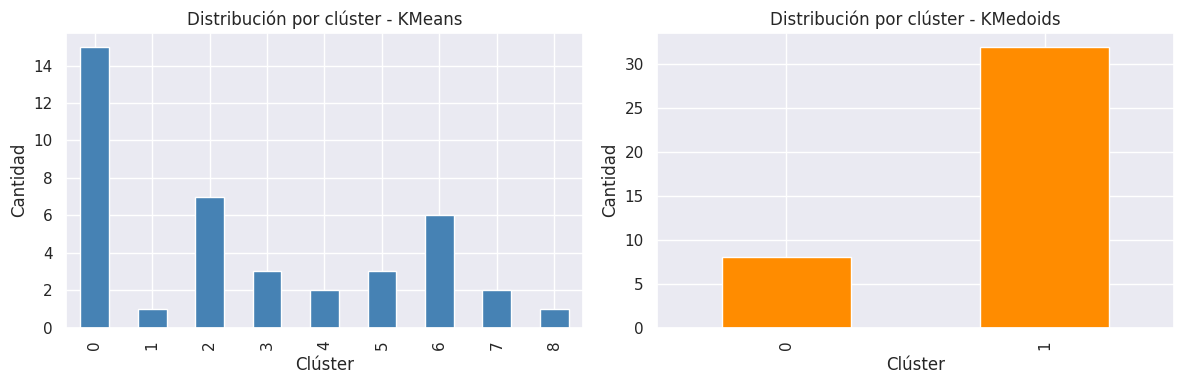

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

df_raw['cluster_kmeans'].value_counts().sort_index().plot(kind='bar', ax=ax[0], color='steelblue')
ax[0].set_title("Distribución por clúster - KMeans")
ax[0].set_xlabel("Clúster")
ax[0].set_ylabel("Cantidad")

df_raw['cluster_kmedoids'].value_counts().sort_index().plot(kind='bar', ax=ax[1], color='darkorange')
ax[1].set_title("Distribución por clúster - KMedoids")
ax[1].set_xlabel("Clúster")
ax[1].set_ylabel("Cantidad")

plt.tight_layout()
plt.show()

### Embeddings con Gemini

En esta sección se generan embeddings para cada muestra del dataset utilizando Gemini. Para ello, cada ejecutable se transforma en una descripción textual basada en las características extraídas del encabezado PE, como imports, DLLs, número de secciones, entropía y tamaños de código y datos.

Posteriormente, estos embeddings se proyectan en dos dimensiones para visualizarlos y analizar si su agrupación es consistente con los clusters obtenidos previamente mediante K-Means y K-Medoids.

In [16]:
def construir_texto(row):
    imports_txt = ", ".join(row["imports"][:20]) if isinstance(row["imports"], list) else ""
    dlls_txt = ", ".join(row["dlls"][:10]) if isinstance(row["dlls"], list) else ""

    return f"""
    Ejecutable PE.
    Empaquetado: {row['empaquetado']}.
    Razon de packing: {row['razon_packing']}.
    Numero de secciones: {row['num_secciones']}.
    Entropia promedio: {row['entropia_promedio']}.
    Tamano de codigo: {row['tam_code']}.
    Tamano de datos inicializados: {row['tam_data']}.
    Numero de exports: {row['num_exports']}.
    Arquitectura: {row['arquitectura']}.
    Subsistema: {row['subsistema']}.
    DLLs principales: {dlls_txt}.
    Imports principales: {imports_txt}.
    """

df_raw["texto_embedding"] = df_raw.apply(construir_texto, axis=1)
df_raw[["archivo", "texto_embedding"]].head(2)

,archivo,texto_embedding
0,F6655E39465C2FF5B016980D918EA028,\n Ejecutable PE.\n Empaquetado: True.\n...
1,GBV66_8F259BB36E00D124963CFA9B86F502E,\n Ejecutable PE.\n Empaquetado: False.\...


In [17]:
from dotenv import load_dotenv
import os

load_dotenv()  # carga el archivo .env

True

#### Generación de embeddings con Gemini

Se utiliza el modelo `gemini-embedding-001` con una tarea de tipo `CLUSTERING`, ya que este tipo de embeddings está orientado a preservar similitudes útiles para agrupamiento.

In [18]:
from google import genai
from google.genai import types
client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])
textos = df_raw["texto_embedding"].tolist()

result = client.models.embed_content(
    model="gemini-embedding-001",
    contents=textos,
    config=types.EmbedContentConfig(
        task_type="CLUSTERING"
    )
)

embeddings = np.array([e.values for e in result.embeddings])
embeddings.shape

(40, 3072)

#### Reducción de dimensionalidad de los embeddings

Para visualizar los embeddings en dos dimensiones, se aplica primero una reducción intermedia con PCA y luego t-SNE. Esto ayuda a estabilizar la proyección y a separar mejor visualmente los grupos en el plano.

In [19]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import pandas as pd

# Reducción previa para estabilizar t-SNE
pca_emb = PCA(n_components=min(20, embeddings.shape[1]), random_state=42)
emb_pca = pca_emb.fit_transform(embeddings)

tsne_emb = TSNE(
    n_components=2,
    random_state=42,
    perplexity=5,
    learning_rate="auto",
    init="pca"
)

emb_2d = tsne_emb.fit_transform(emb_pca)

df_emb = pd.DataFrame({
    "x": emb_2d[:, 0],
    "y": emb_2d[:, 1],
    "archivo": df_raw["archivo"].values,
    "cluster_kmeans": df_raw["cluster_kmeans"].values,
    "cluster_kmedoids": df_raw["cluster_kmedoids"].values
})

df_emb.head()

,x,y,archivo,cluster_kmeans,cluster_kmedoids
0,-22.345528,-220.287140,F6655E39465C2FF5B016980D918EA028,6,1
1,-211.707855,-45.732559,GBV66_8F259BB36E00D124963CFA9B86F502E,2,0
2,223.832443,-119.127594,FGTR43_EF8E0FB20E7228C7492CCDC59D87C690,7,1
3,215.061401,-50.274059,VC990_468FF2C12CFFC7E5B2FE0EE6BB3B239E,4,1
4,20.380182,-60.129314,VBMM9_149B7BD7218AAB4E257D28469FDDB0D,5,1


### Visualización de embeddings coloreados por K-Means

En esta gráfica se visualizan los embeddings proyectados en dos dimensiones y coloreados según las etiquetas generadas previamente por K-Means. Esto permite analizar si las agrupaciones semánticas inducidas por Gemini son similares a los clusters encontrados a partir de las características estructurales del malware.

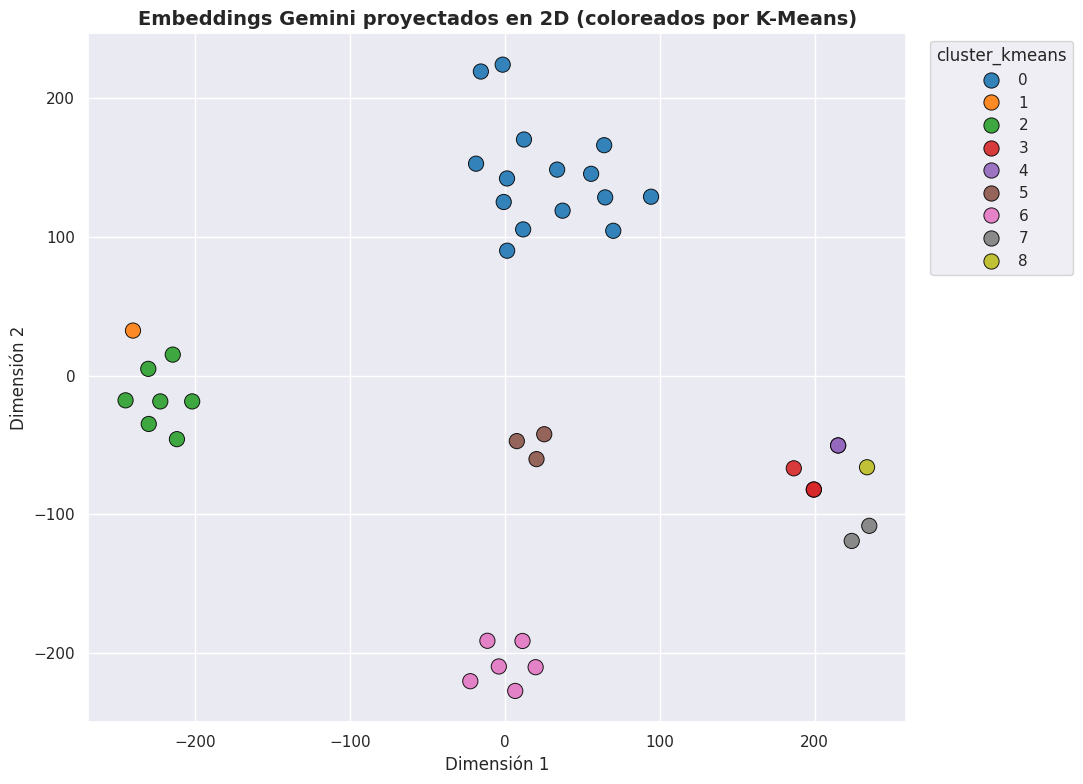

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(11, 8))

sns.scatterplot(
    data=df_emb,
    x="x",
    y="y",
    hue="cluster_kmeans",
    palette="tab10",
    s=120,
    edgecolor="black",
    linewidth=0.7,
    alpha=0.9
)

plt.title("Embeddings Gemini proyectados en 2D (coloreados por K-Means)", fontsize=14, fontweight="bold")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.legend(title="cluster_kmeans", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Visualización de embeddings coloreados por K-Medoids

En esta gráfica se muestran los mismos embeddings proyectados en dos dimensiones, pero coloreados según las etiquetas generadas por K-Medoids. Esto permite comparar si la estructura semántica de los embeddings también es consistente con este segundo algoritmo de particionamiento.

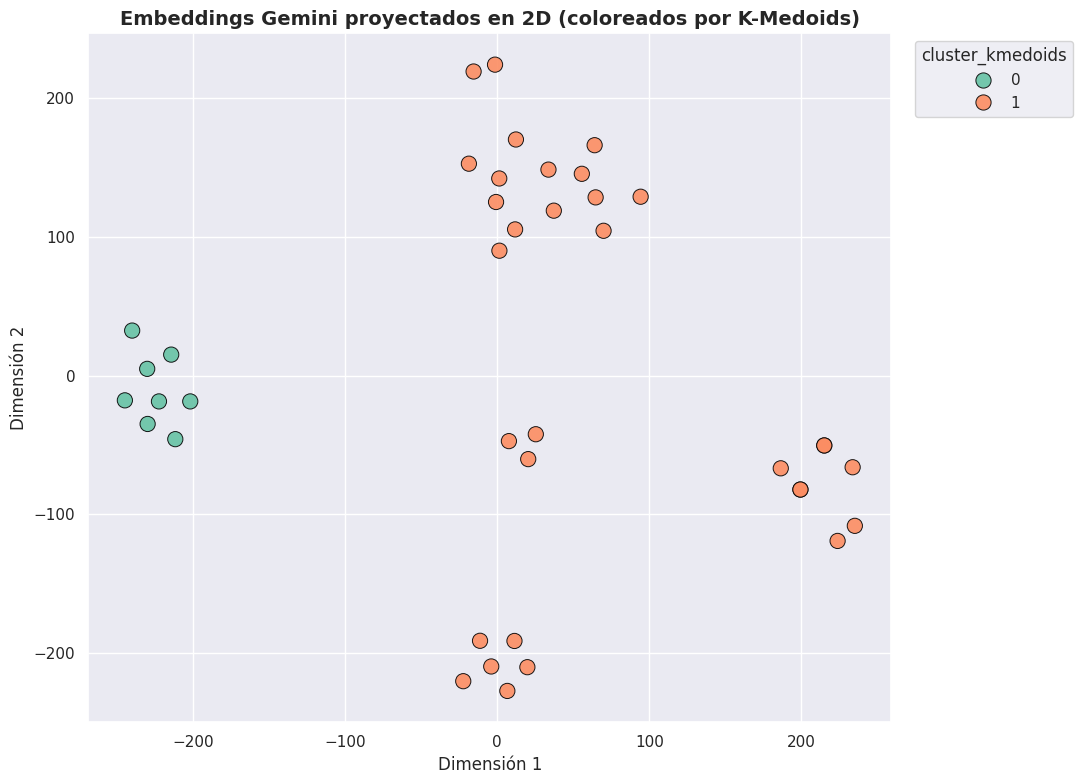

In [21]:
plt.figure(figsize=(11, 8))

sns.scatterplot(
    data=df_emb,
    x="x",
    y="y",
    hue="cluster_kmedoids",
    palette="Set2",
    s=120,
    edgecolor="black",
    linewidth=0.7,
    alpha=0.9
)

plt.title("Embeddings Gemini proyectados en 2D (coloreados por K-Medoids)", fontsize=14, fontweight="bold")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.legend(title="cluster_kmedoids", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Análisis de similitud con índice de Jaccard

En esta sección se aplica el índice de Jaccard para medir similitud entre muestras de malware utilizando dos tipos de características:

- Strings extraídas de los ejecutables
- Llamadas a funciones importadas (imports)

Se generan grafos de similitud con tres umbrales distintos. Cada nodo representa una muestra de malware y se agrega una arista entre dos nodos cuando la similitud entre sus características supera el umbral definido.

**Índice de Jaccard**

El índice de Jaccard mide la similitud entre dos conjuntos como la razón entre la intersección y la unión de sus elementos.

In [22]:
import networkx as nx
from networkx.drawing.nx_pydot import write_dot
import pydot

def jaccard_similarity(set1, set2):
    set1 = set(set1) if set1 is not None else set()
    set2 = set(set2) if set2 is not None else set()

    union = set1.union(set2)
    if len(union) == 0:
        return 0.0

    intersection = set1.intersection(set2)
    return len(intersection) / len(union)

#### Función para construir el grafo de similitud

Esta función genera un grafo donde cada nodo es un ejecutable y cada arista representa una similitud de Jaccard superior al umbral indicado.

In [23]:
def construir_grafo_jaccard(df, feature_col, threshold, label_len=14):
    G = nx.Graph()

    # agregar nodos
    for _, row in df.iterrows():
        archivo = row["archivo"]
        G.add_node(
            archivo,
            label=str(archivo)[:label_len]
        )

    # comparar pares
    for (_, row1), (_, row2) in itertools.combinations(df.iterrows(), 2):
        f1 = row1[feature_col]
        f2 = row2[feature_col]

        score = jaccard_similarity(f1, f2)

        if score >= threshold:
            G.add_edge(
                row1["archivo"],
                row2["archivo"],
                weight=round(score, 4),
                penwidth=1 + (score - threshold) * 10
            )

    return G

#### Función para guardar el grafo en DOT y PNG

Como el ejemplo de canvas que primero se exporta el grafo a `.dot` y luego se renderiza a `.png` con Graphviz.

In [24]:
def guardar_grafo_dot_png(G, out_base, layout_engine="sfdp"):
    """
    out_base: ruta sin extensión
    genera:
      - out_base.dot
      - out_base.png
    """

    dot_path = f"{out_base}.dot"
    png_path = f"{out_base}.png"

    write_dot(G, dot_path)

    # renderizar con graphviz
    subprocess.run(
        [layout_engine, "-Tpng", dot_path, "-o", png_path],
        check=True
    )

    return dot_path, png_path

### Preparación de carpetas de salida

Los grafos se guardarán dentro de una carpeta llamada `grafos` en la misma carpeta del notebook. Y como son muchos archivos, lo mejor fue crear 2 subcarpetas, 1 para strings `grafos/strings`y otra para los imports `grafo/imports`

In [25]:
OUTPUT_DIR = "grafos"
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_DIR_STRINGS = "grafos/strings"
os.makedirs(OUTPUT_DIR_STRINGS, exist_ok=True)
OUTPUT_DIR_STRINGS_GLO = "grafos/strings/globales"
os.makedirs(OUTPUT_DIR_STRINGS_GLO, exist_ok=True)
OUTPUT_DIR_STRINGS_FAM = "grafos/strings/familias"
os.makedirs(OUTPUT_DIR_STRINGS_FAM, exist_ok=True)

OUTPUT_DIR_IMPORTS = "grafos/imports"
os.makedirs(OUTPUT_DIR_IMPORTS, exist_ok=True)
OUTPUT_DIR_IMPORTS_GLO = "grafos/imports/globales"
os.makedirs(OUTPUT_DIR_IMPORTS_GLO, exist_ok=True)
OUTPUT_DIR_IMPORTS_FAM = "grafos/imports/familias"
os.makedirs(OUTPUT_DIR_IMPORTS_FAM, exist_ok=True)
# De paso colocamos los umbrales de una vez
thresholds = [0.6, 0.8, 0.95]
print("Carpeta de salida general:", OUTPUT_DIR)

Carpeta de salida general: grafos


In [26]:
# Crear Familias
familias = sorted(df_raw["cluster_kmeans"].unique())
familias

[np.int32(0),
 np.int32(1),
 np.int32(2),
 np.int32(3),
 np.int32(4),
 np.int32(5),
 np.int32(6),
 np.int32(7),
 np.int32(8)]

**Grafos Strings**

In [27]:
# Globales Strings
for t in thresholds:
    G = construir_grafo_jaccard(df_raw, "strings", t)
    out_base = os.path.join(OUTPUT_DIR_STRINGS_GLO, f"global_strings_{str(t).replace('.', '_')}")
    dot_path, png_path = guardar_grafo_dot_png(G, out_base)
    print("Generado:", dot_path, "y", png_path)

Generado: grafos/strings/globales/global_strings_0_6.dot y grafos/strings/globales/global_strings_0_6.png
Generado: grafos/strings/globales/global_strings_0_8.dot y grafos/strings/globales/global_strings_0_8.png
Generado: grafos/strings/globales/global_strings_0_95.dot y grafos/strings/globales/global_strings_0_95.png


In [28]:
for familia in familias:
    df_fam = df_raw[df_raw["cluster_kmeans"] == familia].copy()

    for t in thresholds:
        G = construir_grafo_jaccard(df_fam, "strings", t)
        out_base = os.path.join(
            OUTPUT_DIR_STRINGS_FAM,
            f"familia_{familia}_strings_{str(t).replace('.', '_')}"
        )
        dot_path, png_path = guardar_grafo_dot_png(G, out_base)
        print("Generado:", dot_path, "y", png_path)

Generado: grafos/strings/familias/familia_0_strings_0_6.dot y grafos/strings/familias/familia_0_strings_0_6.png
Generado: grafos/strings/familias/familia_0_strings_0_8.dot y grafos/strings/familias/familia_0_strings_0_8.png
Generado: grafos/strings/familias/familia_0_strings_0_95.dot y grafos/strings/familias/familia_0_strings_0_95.png
Generado: grafos/strings/familias/familia_1_strings_0_6.dot y grafos/strings/familias/familia_1_strings_0_6.png
Generado: grafos/strings/familias/familia_1_strings_0_8.dot y grafos/strings/familias/familia_1_strings_0_8.png
Generado: grafos/strings/familias/familia_1_strings_0_95.dot y grafos/strings/familias/familia_1_strings_0_95.png
Generado: grafos/strings/familias/familia_2_strings_0_6.dot y grafos/strings/familias/familia_2_strings_0_6.png
Generado: grafos/strings/familias/familia_2_strings_0_8.dot y grafos/strings/familias/familia_2_strings_0_8.png
Generado: grafos/strings/familias/familia_2_strings_0_95.dot y grafos/strings/familias/familia_2_str

**Imports**

In [29]:
for t in thresholds:
    G = construir_grafo_jaccard(df_raw, "imports", t)
    out_base = os.path.join(OUTPUT_DIR_IMPORTS_GLO, f"global_imports_{str(t).replace('.', '_')}")
    dot_path, png_path = guardar_grafo_dot_png(G, out_base)
    print("Generado:", dot_path, "y", png_path)

Generado: grafos/imports/globales/global_imports_0_6.dot y grafos/imports/globales/global_imports_0_6.png
Generado: grafos/imports/globales/global_imports_0_8.dot y grafos/imports/globales/global_imports_0_8.png
Generado: grafos/imports/globales/global_imports_0_95.dot y grafos/imports/globales/global_imports_0_95.png


In [31]:
for familia in familias:
    df_fam = df_raw[df_raw["cluster_kmeans"] == familia].copy()

    for t in thresholds:
        G = construir_grafo_jaccard(df_fam, "imports", t)
        out_base = os.path.join(
            OUTPUT_DIR_IMPORTS_FAM,
            f"familia_{familia}_imports_{str(t).replace('.', '_')}"
        )
        dot_path, png_path = guardar_grafo_dot_png(G, out_base)
        print("Generado:", dot_path, "y", png_path)

Generado: grafos/imports/familias/familia_0_imports_0_6.dot y grafos/imports/familias/familia_0_imports_0_6.png
Generado: grafos/imports/familias/familia_0_imports_0_8.dot y grafos/imports/familias/familia_0_imports_0_8.png
Generado: grafos/imports/familias/familia_0_imports_0_95.dot y grafos/imports/familias/familia_0_imports_0_95.png
Generado: grafos/imports/familias/familia_1_imports_0_6.dot y grafos/imports/familias/familia_1_imports_0_6.png
Generado: grafos/imports/familias/familia_1_imports_0_8.dot y grafos/imports/familias/familia_1_imports_0_8.png
Generado: grafos/imports/familias/familia_1_imports_0_95.dot y grafos/imports/familias/familia_1_imports_0_95.png
Generado: grafos/imports/familias/familia_2_imports_0_6.dot y grafos/imports/familias/familia_2_imports_0_6.png
Generado: grafos/imports/familias/familia_2_imports_0_8.dot y grafos/imports/familias/familia_2_imports_0_8.png
Generado: grafos/imports/familias/familia_2_imports_0_95.dot y grafos/imports/familias/familia_2_imp